# Steady Case 0 solution — Berton (2023) Section 3

This notebook reproduces the steady Case 0 solution (`z_W0 = 10 km`; paper Figures 7–15).

Common simulation conversion and plotting code lives in `cloud_rom.berton2023_plots`. The simulation disables Coriolis to match the paper.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

repo = Path.cwd().resolve()
if repo.name == "notebooks":
    repo = repo.parent
src = repo / "src"
if src.exists() and str(src) not in sys.path:
    sys.path.insert(0, str(src))

from cloud_rom import berton2023 as b
from cloud_rom import berton2023_plots as bp

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True})

## Run simulation

Increase `SAMPLES` for denser plotted curves; it does not change the integration timestep. The resulting CSV contains plain numeric magnitudes, not Pint quantity strings.

In [3]:
REQUESTED_DURATION_H = 5.0
DT_S = 0.02
SAMPLES = 1800
OSCILLATORY = False

atm = b.atmosphere_for_case(0, oscillatory=OSCILLATORY)
df = bp.run_case0(
    oscillatory=OSCILLATORY,
    duration_h=REQUESTED_DURATION_H,
    dt_s=DT_S,
    samples=SAMPLES,
    include_coriolis=False,
    progress=True,
)
bp.summarize_run(df, requested_duration_h=REQUESTED_DURATION_H)

data = bp.magnitude_frame(df, atm)
csv_path = bp.export_magnitudes(data, repo / "notebooks" / "df_steady_magnitudes.csv")
print(f"Wrote {csv_path}")
data.head()

steady Case 0:   0%|          | 0/900001 [00:00<?, ?step/s]

Rows: 1801
Last sampled time: 5.000 h (requested 5.000 h)
Last sampled mass: 0.2124 µg
Wrote /home/iross/research/ongoing/ai-class/code/cloud-rom/notebooks/df_steady_magnitudes.csv


,t_h,x_km,z_km,u_m_s,w_m_s,m_ug,a_um,c_um,cB_um,Di_um,...,dT_mK,Siminus1_pct,R_pct,drive_pct,psi,CD,Re,x_minus_x0_km,z_minus_z0_km,Wf_m_s
0,0.000000,2.000000,10.000000,0.000000,0.600000,0.935543,51.100000,102.200000,20.44,124.764911,...,5.784852,3.103942,0.883524,2.220418,0.800000,11.326126,2.078799,0.000000,0.000000,0.000000
1,0.002778,1.999988,10.000440,-0.002187,0.040867,0.935885,51.106410,102.212819,20.44,124.780086,...,5.770752,3.098586,0.883638,2.214947,0.800025,11.323366,2.079380,-0.000012,0.000440,-0.559133
2,0.005556,1.999956,10.000848,-0.004227,0.040750,0.936226,51.112809,102.225617,20.44,124.795237,...,5.757671,3.093613,0.883753,2.209861,0.800050,11.320572,2.079968,-0.000044,0.000848,-0.559250
3,0.008333,1.999904,10.001255,-0.006262,0.040633,0.936566,51.119192,102.238385,20.44,124.810351,...,5.744626,3.088655,0.883867,2.204789,0.800075,11.317786,2.080555,-0.000096,0.001255,-0.559367
4,0.011111,1.999831,10.001660,-0.008290,0.040516,0.936905,51.125561,102.251122,20.44,124.825429,...,5.731618,3.083712,0.883980,2.199731,0.800100,11.315007,2.081140,-0.000169,0.001660,-0.559484


## Check initial rows

In [4]:
data[["t_h", "x_km", "z_km", "x_minus_x0_km", "z_minus_z0_km", "m_ug", "Re", "CD"]].head(10)

,t_h,x_km,z_km,x_minus_x0_km,z_minus_z0_km,m_ug,Re,CD
0,0.000000,2.000000,10.000000,0.000000,0.000000,0.935543,2.078799,11.326126
1,0.002778,1.999988,10.000440,-0.000012,0.000440,0.935885,2.079380,11.323366
2,0.005556,1.999956,10.000848,-0.000044,0.000848,0.936226,2.079968,11.320572
3,0.008333,1.999904,10.001255,-0.000096,0.001255,0.936566,2.080555,11.317786
4,0.011111,1.999831,10.001660,-0.000169,0.001660,0.936905,2.081140,11.315007
5,0.013889,1.999738,10.002065,-0.000262,0.002065,0.937244,2.081725,11.312236
6,0.016667,1.999625,10.002468,-0.000375,0.002468,0.937582,2.082308,11.309473
7,0.019444,1.999492,10.002871,-0.000508,0.002871,0.937919,2.082889,11.306717
8,0.022222,1.999338,10.003272,-0.000662,0.003272,0.938256,2.083470,11.303968
9,0.025000,1.999165,10.003672,-0.000835,0.003672,0.938592,2.084049,11.301228


## Trajectory and hodograph

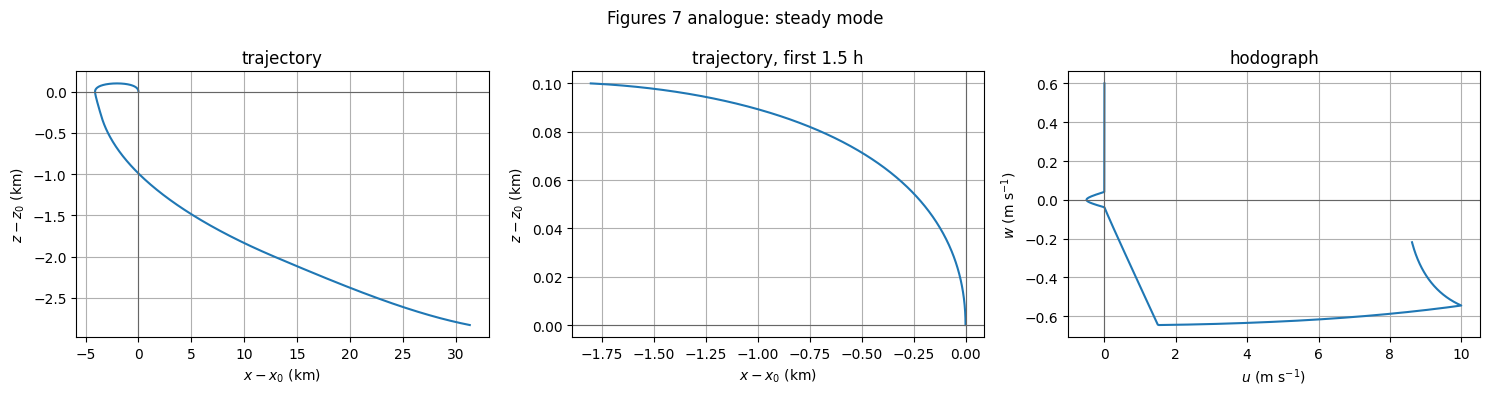

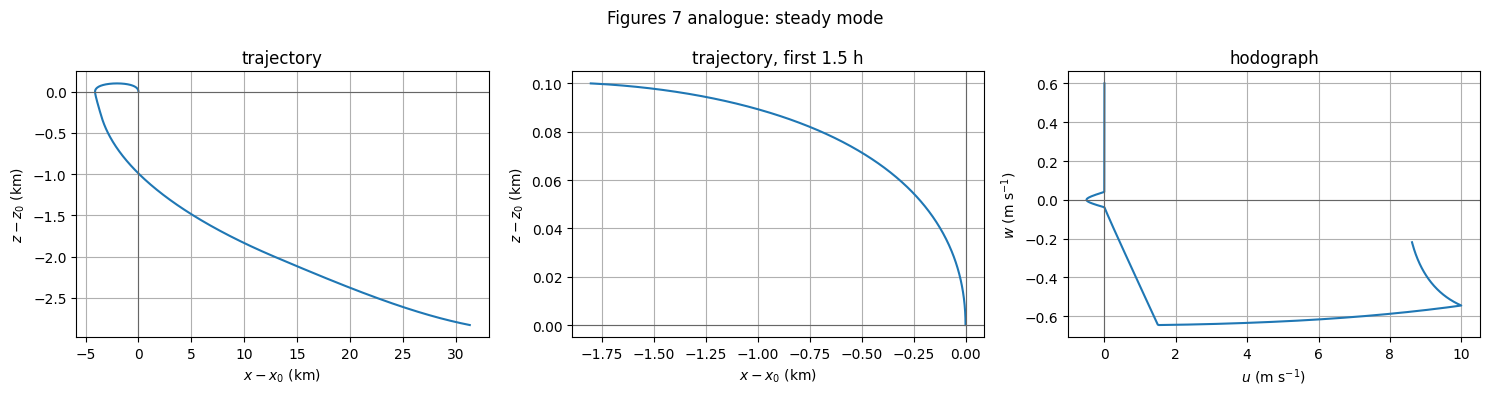

In [5]:
bp.plot_trajectory_hodograph(
    data,
    "Figures 7 analogue: steady mode",
    early_hours=1.5,
)

## Abscissa and altitude vs time

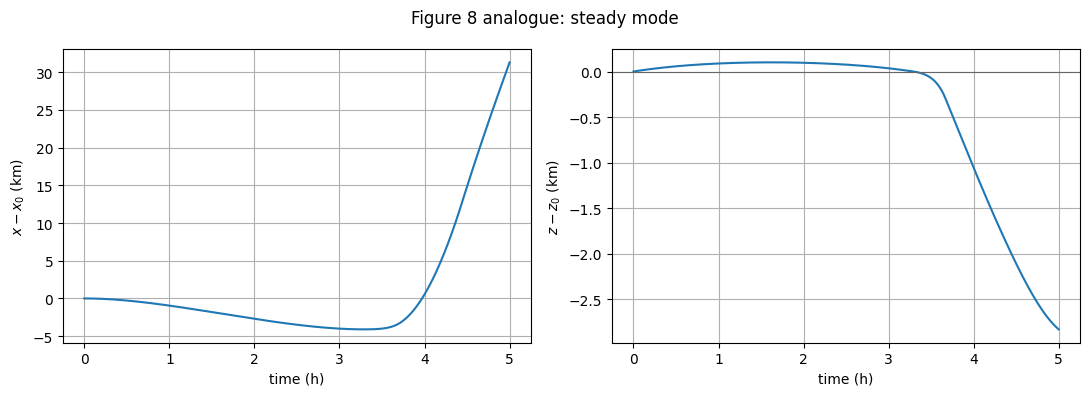

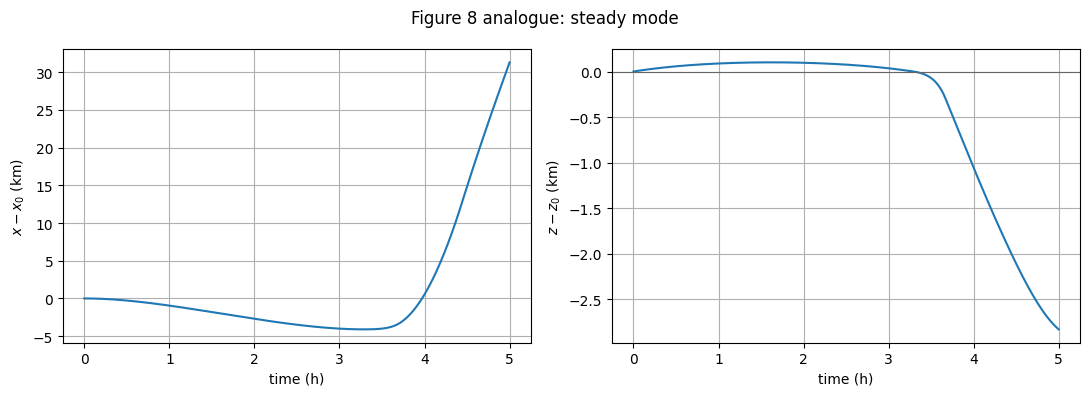

In [6]:
bp.plot_x_z(data, "Figure 8 analogue: steady mode")

## Fall speed, supersaturation, radiation, driving factor

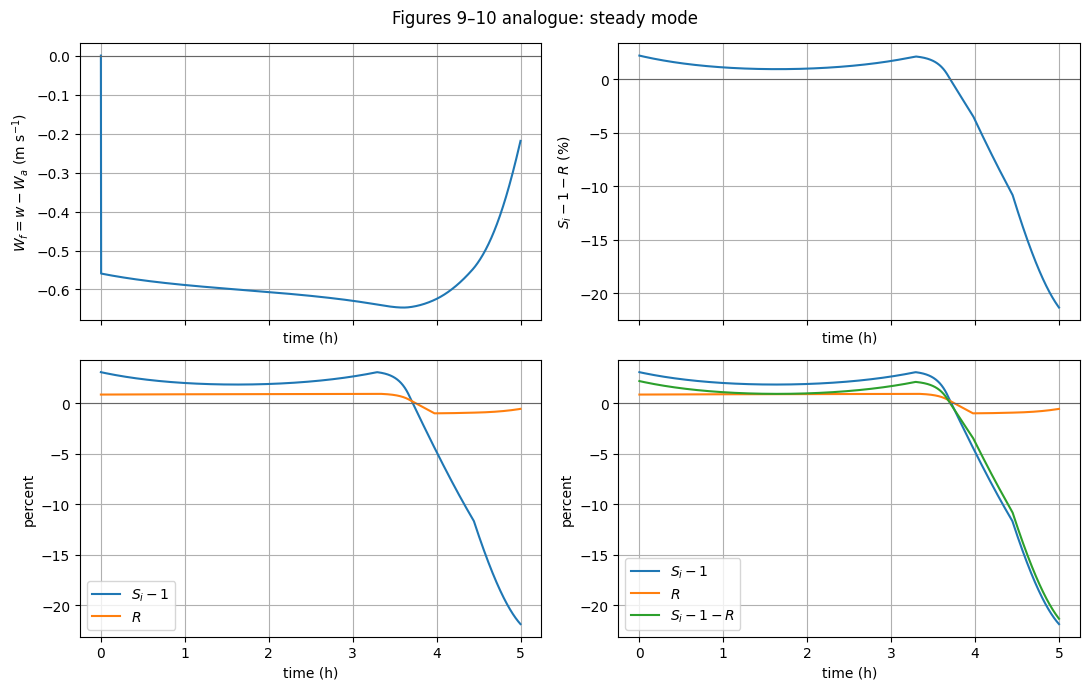

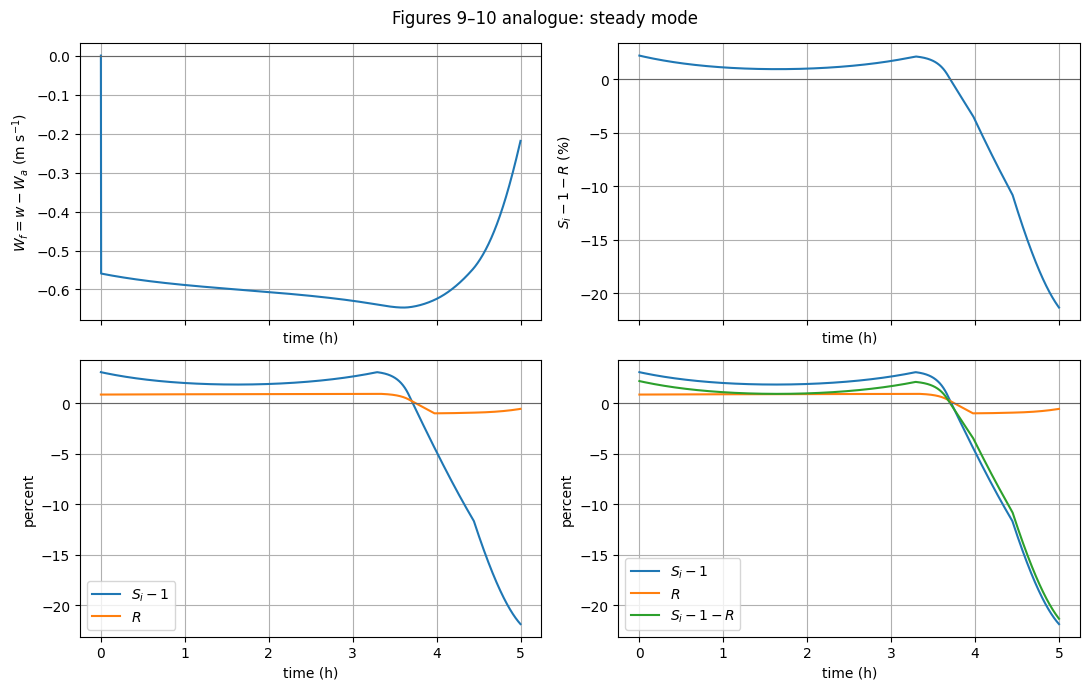

In [7]:
bp.plot_microphysics_drivers(data, "Figures 9–10 analogue: steady mode")

## Mass, dimensions, equivalent diameter, viscosity

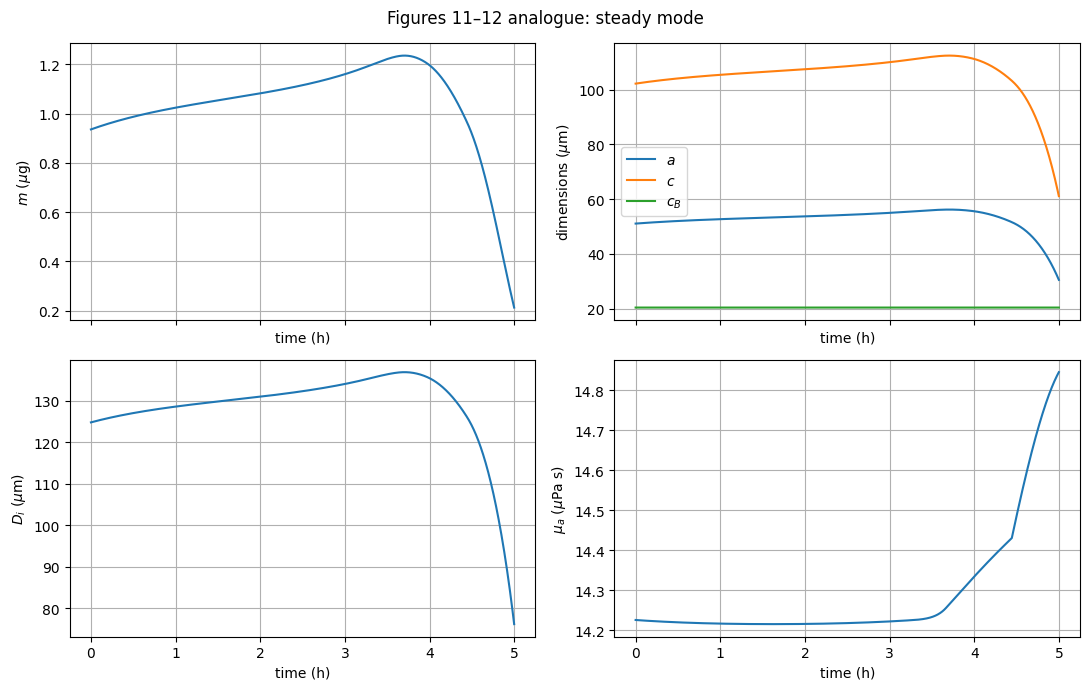

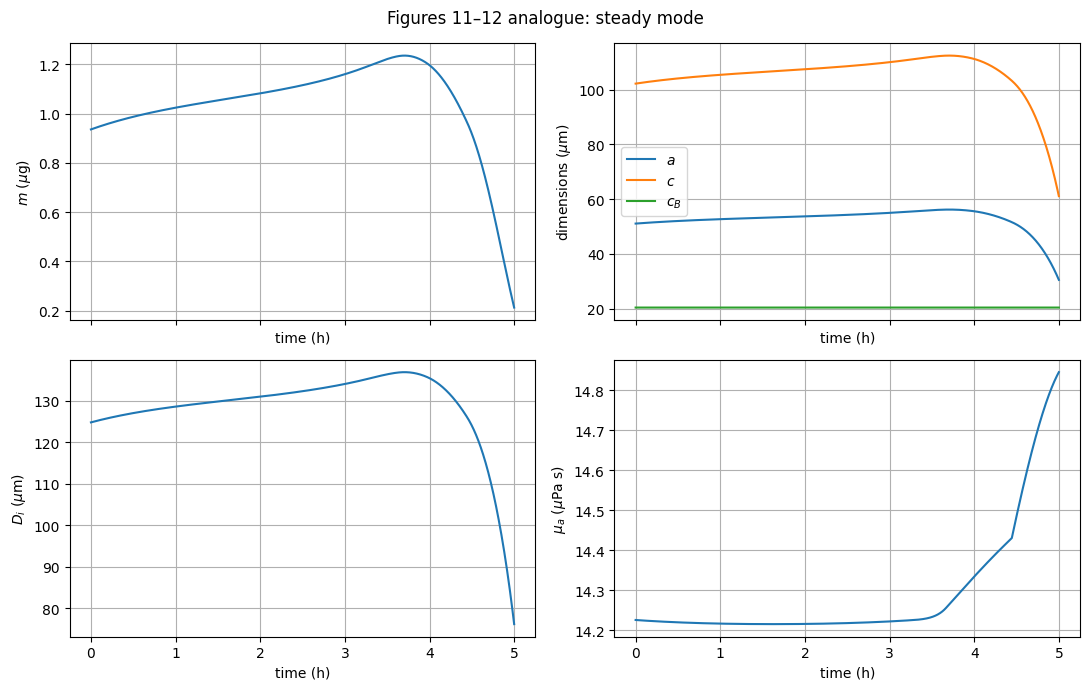

In [8]:
bp.plot_size_state(data, "Figures 11–12 analogue: steady mode")

## Shape, drag, damping, temperature difference

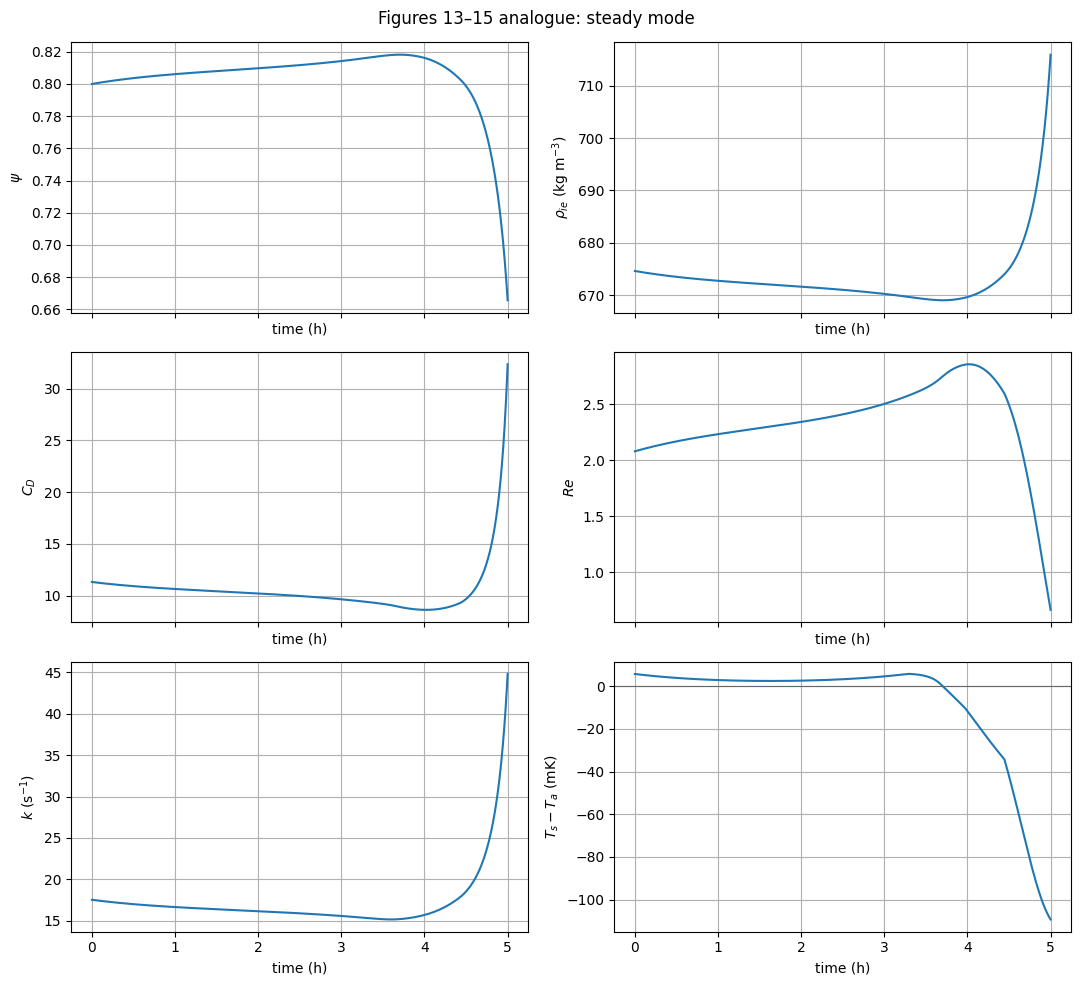

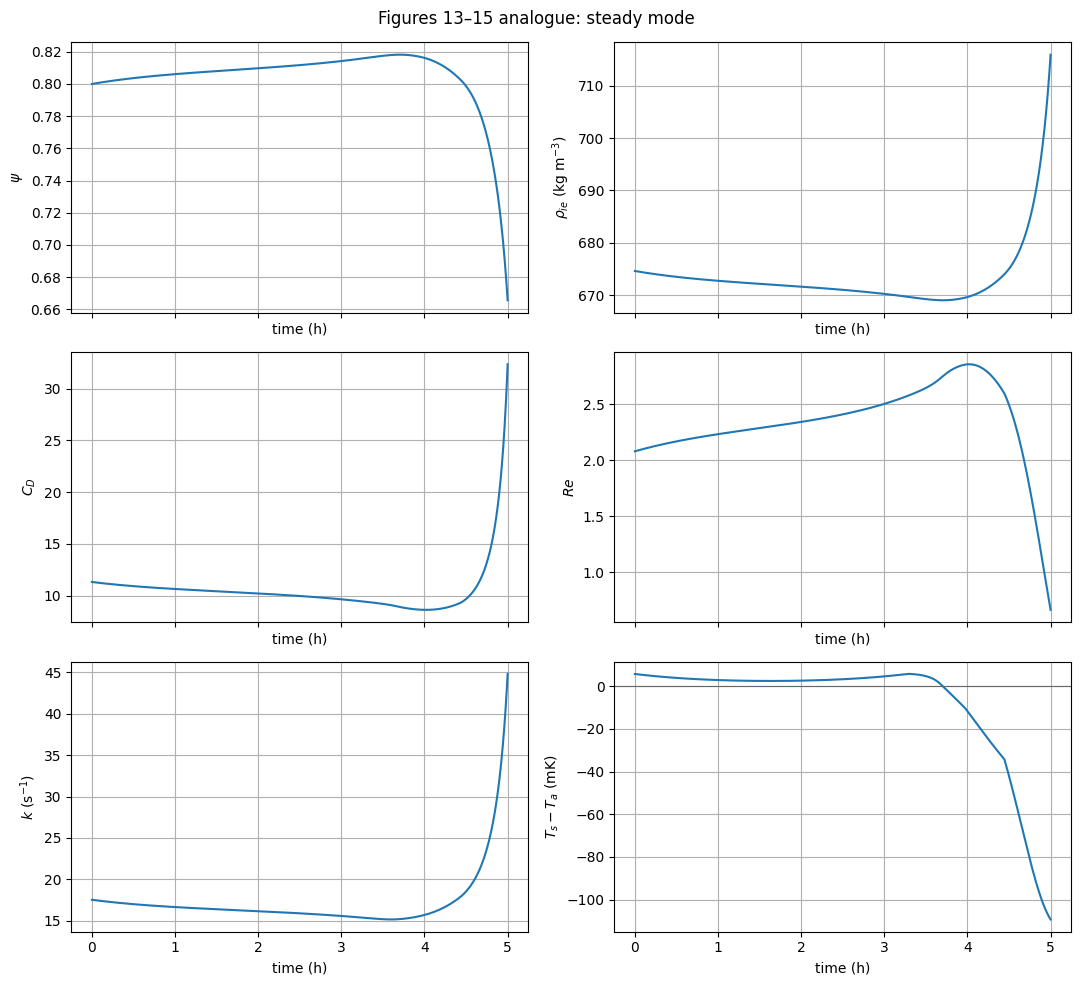

In [9]:
bp.plot_drag_state(data, "Figures 13–15 analogue: steady mode")

## Reload saved numeric CSV

In [2]:
reloaded = pd.read_csv(repo / "notebooks" / "df_steady_magnitudes.csv")
reloaded.head()

,t_h,x_km,z_km,u_m_s,w_m_s,m_ug,a_um,c_um,cB_um,Di_um,...,dT_mK,Siminus1_pct,R_pct,drive_pct,psi,CD,Re,x_minus_x0_km,z_minus_z0_km,Wf_m_s
0,0.000000,2.000000,10.000000,0.000000,0.600000,0.935543,51.100000,102.200000,20.44,124.764911,...,5.784852,3.103942,0.883524,2.220418,0.800000,11.326126,2.078799,0.000000,0.000000,0.000000
1,0.002778,1.999988,10.000440,-0.002187,0.040867,0.935885,51.106410,102.212819,20.44,124.780086,...,5.770752,3.098586,0.883638,2.214947,0.800025,11.323366,2.079380,-0.000012,0.000440,-0.559133
2,0.005556,1.999956,10.000848,-0.004227,0.040750,0.936226,51.112809,102.225617,20.44,124.795237,...,5.757671,3.093613,0.883753,2.209861,0.800050,11.320572,2.079968,-0.000044,0.000848,-0.559250
3,0.008333,1.999904,10.001255,-0.006262,0.040633,0.936566,51.119192,102.238385,20.44,124.810351,...,5.744626,3.088655,0.883867,2.204789,0.800075,11.317786,2.080555,-0.000096,0.001255,-0.559367
4,0.011111,1.999831,10.001660,-0.008290,0.040516,0.936905,51.125561,102.251122,20.44,124.825429,...,5.731618,3.083712,0.883980,2.199731,0.800100,11.315007,2.081140,-0.000169,0.001660,-0.559484


In [3]:
data = reloaded